In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit_optimization.applications import Knapsack
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.circuit.library import QAOAAnsatz
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, generate_qiskit_param_map,relax_qaoa_parameters
from testing_scripts.qaoa_utils import evaluate_energy, QAOASolver
from testing_scripts.knapsack_utils import generate_knapsack_instance

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [38]:
# prob = Knapsack(values=[3, 4, 5, 6, 7,8,9,10,11,12], weights=[2, 3, 4, 5, 6,7,8,9,10,11], max_weight=10)

# Example usage
prob = generate_knapsack_instance(num_items=8,seed=1)

In [39]:
# prob = Knapsack(values=[3, 4, 5, 6, 7,8,9,10,11,12], weights=[2, 3, 4, 5, 6,7,8,9,10,11], max_weight=10)
qp = prob.to_quadratic_program()
print(qp.prettyprint())

Problem name: Knapsack

Maximize
  5*x_0 + 19*x_1 + 3*x_2 + 9*x_3 + 4*x_4 + 16*x_5 + 15*x_6 + 16*x_7

Subject to
  Linear constraints (1)
    11*x_0 + 7*x_1 + 13*x_2 + 4*x_3 + 2*x_4 + 8*x_5 + x_6 + 15*x_7 <= 30  'c0'

  Binary variables (8)
    x_0 x_1 x_2 x_3 x_4 x_5 x_6 x_7



In [ ]:
# intermediate QUBO form of the optimization problem
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)
print(qubo.prettyprint())

Problem name: Knapsack

Minimize
  88*c0@int_slack@0^2 + 352*c0@int_slack@0*c0@int_slack@1
  + 704*c0@int_slack@0*c0@int_slack@2 + 1408*c0@int_slack@0*c0@int_slack@3
  + 2640*c0@int_slack@0*c0@int_slack@4 + 352*c0@int_slack@1^2
  + 1408*c0@int_slack@1*c0@int_slack@2 + 2816*c0@int_slack@1*c0@int_slack@3
  + 5280*c0@int_slack@1*c0@int_slack@4 + 1408*c0@int_slack@2^2
  + 5632*c0@int_slack@2*c0@int_slack@3 + 10560*c0@int_slack@2*c0@int_slack@4
  + 5632*c0@int_slack@3^2 + 21120*c0@int_slack@3*c0@int_slack@4
  + 19800*c0@int_slack@4^2 + 1936*x_0*c0@int_slack@0 + 3872*x_0*c0@int_slack@1
  + 7744*x_0*c0@int_slack@2 + 15488*x_0*c0@int_slack@3
  + 29040*x_0*c0@int_slack@4 + 10648*x_0^2 + 13552*x_0*x_1 + 25168*x_0*x_2
  + 7744*x_0*x_3 + 3872*x_0*x_4 + 15488*x_0*x_5 + 1936*x_0*x_6 + 29040*x_0*x_7
  + 1232*x_1*c0@int_slack@0 + 2464*x_1*c0@int_slack@1 + 4928*x_1*c0@int_slack@2
  + 9856*x_1*c0@int_slack@3 + 18480*x_1*c0@int_slack@4 + 4312*x_1^2
  + 16016*x_1*x_2 + 4928*x_1*x_3 + 2464*x_1*x_4 + 9856*x

In [41]:
# qubit Hamiltonian and offset
op, offset = qubo.to_ising()
print(f"num qubits: {op.num_qubits}, offset: {offset}\n")
print(op)
cost_hamiltonian = op

num qubits: 13, offset: 42196.5

SparsePauliOp(['IIIIIIIIIIIIZ', 'IIIIIIIIIIIZI', 'IIIIIIIIIIZII', 'IIIIIIIIIZIII', 'IIIIIIIIZIIII', 'IIIIIIIZIIIII', 'IIIIIIZIIIIII', 'IIIIIZIIIIIII', 'IIIIZIIIIIIII', 'IIIZIIIIIIIII', 'IIZIIIIIIIIII', 'IZIIIIIIIIIII', 'ZIIIIIIIIIIII', 'IIIIIIIIIIIZZ', 'IIIIIIIIIIZIZ', 'IIIIIIIIIZIIZ', 'IIIIIIIIZIIIZ', 'IIIIIIIZIIIIZ', 'IIIIIIZIIIIIZ', 'IIIIIZIIIIIIZ', 'IIIIZIIIIIIIZ', 'IIIZIIIIIIIIZ', 'IIZIIIIIIIIIZ', 'IZIIIIIIIIIIZ', 'ZIIIIIIIIIIIZ', 'IIIIIIIIIIZZI', 'IIIIIIIIIZIZI', 'IIIIIIIIZIIZI', 'IIIIIIIZIIIZI', 'IIIIIIZIIIIZI', 'IIIIIZIIIIIZI', 'IIIIZIIIIIIZI', 'IIIZIIIIIIIZI', 'IIZIIIIIIIIZI', 'IZIIIIIIIIIZI', 'ZIIIIIIIIIIZI', 'IIIIIIIIIZZII', 'IIIIIIIIZIZII', 'IIIIIIIZIIZII', 'IIIIIIZIIIZII', 'IIIIIZIIIIZII', 'IIIIZIIIIIZII', 'IIIZIIIIIIZII', 'IIZIIIIIIIZII', 'IZIIIIIIIIZII', 'ZIIIIIIIIIZII', 'IIIIIIIIZZIII', 'IIIIIIIZIZIII', 'IIIIIIZIIZIII', 'IIIIIZIIIZIII', 'IIIIZIIIIZIII', 'IIIZIIIIIZIII', 'IIZIIIIIIZIII', 'IZIIIIIIIZIII', 'ZIIIIIIIIZIII', 'IIIIIIIZZIIII', 

In [42]:
reps=2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [43]:
knapsack_qaoa = QAOASolver(cost_hamiltonian,circuit)
knapsack_qaoa.prepare_circuit()

In [60]:
# Run CAFQA Process
knapsack_qaoa.run_CAFQA(n_gens=50,err=1e-3)

STARTING ROUND 0


started GA at id 1 with 16 procs

started GA at id 2 with 16 procs

started GA at id 3 with 16 procs
started GA at id None with 16 procs

GA parameters used for this experiment:
  num_generations=25
  num_parents_mating=20
  population_size=100
  num_genes=208
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

GA parameters used for this experiment:
  num_generations=25
  num_parents_mating=20
  population_size=100
  num_genes=208
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
GA parameters used for this experiment:
  num_generations=25
  num_parents_mating=20
  population_size=100
  num_genes=208
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_t

In [61]:
knapsack_qaoa.energy_best

np.float64(-20460.0)

In [62]:
knapsack_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -42259.5


np.float64(-42259.5)

In [63]:
cafqa_angles = [param * np.pi/2 for param in knapsack_qaoa.ks_best]

In [64]:
energies = [evaluate_energy(knapsack_qaoa.pcirc, cost_hamiltonian, cafqa_angles) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average CAFQA Qiskit Energy: {average_energy}")

Average CAFQA Qiskit Energy: -20460.0


In [65]:
# Random Initalization 
random_angles = np.random.random(len(knapsack_qaoa.ks_best))
random_energies = [evaluate_energy(knapsack_qaoa.pcirc, cost_hamiltonian, random_angles) for _ in range(10)]
min_energy = min(random_energies)
print(f"Minimum Energy found with Random initialization over 100 runs: {min_energy}")

Minimum Energy found with Random initialization over 100 runs: 10491.25188261743


In [66]:
cafqa_result,cafqa_iteration_vals = knapsack_qaoa.run_qaoa(cafqa_angles,max_iters=1000,err=1e-3)
random_result,random_iteration_vals = knapsack_qaoa.run_qaoa(random_angles,max_iters=1000,err=1e-3)

Exact Energy from Eigensolver: -42259.5


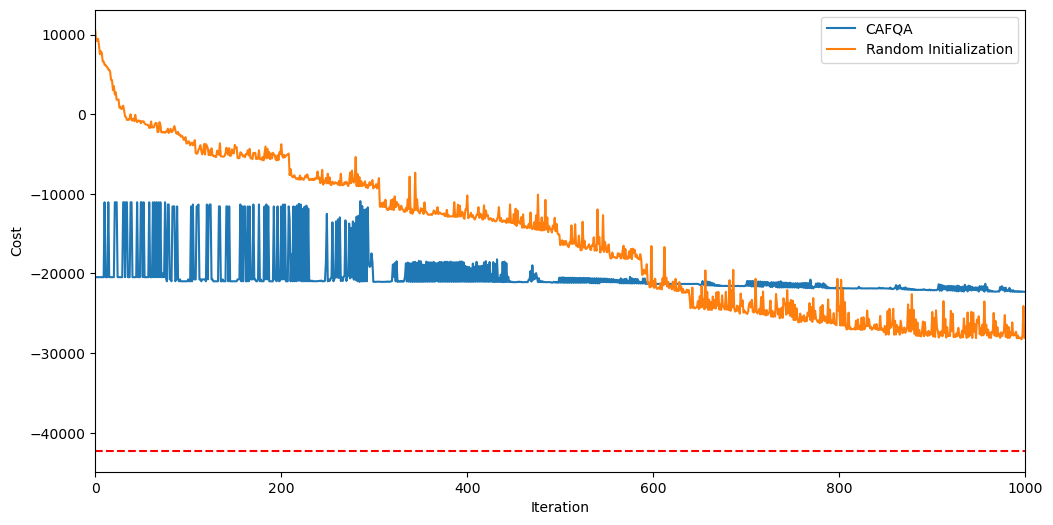

In [68]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_iteration_vals, label="CAFQA")
plt.plot(random_iteration_vals, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.xlim(0,1000)
plt.axhline(knapsack_qaoa.evaluate_exact_energy(), color='r', linestyle='--', label='Exact Energy')
plt.show()

# Vanilla

In [24]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
vanilla_knapsack = QAOASolver(cost_hamiltonian,circuit.decompose().decompose())
vanilla_knapsack.vanilla = True

In [27]:
import os
init_random_params = np.random.random(circuit.num_parameters)
res,obj_values=vanilla_knapsack.run_qaoa(init_random_params, max_iters=1000)
results_dict = {
    "vanilla_fin_energy": res,
    "vanilla_iteration_values": obj_values,
}

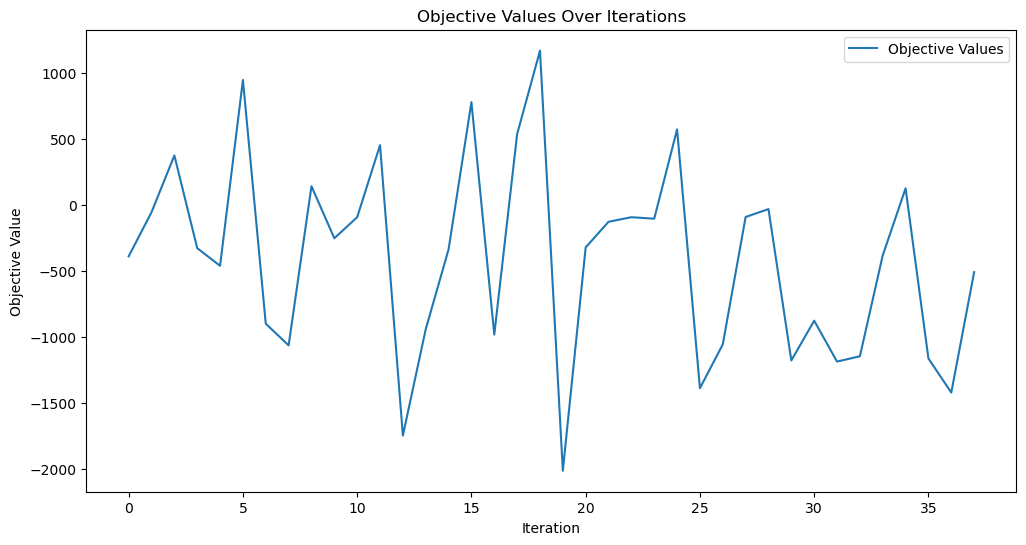

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(obj_values, label="Objective Values")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective Values Over Iterations")
plt.legend()
plt.show()